In [1]:
# imports


import numpy as np
import matplotlib.pyplot as plt
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

#Carga del dataset

In [11]:
VOCAB_SIZE  = 10000
MAX_LEN     = 300

(X_train, y_train), (X_test, y_test) = imdb.load_data(num_words=VOCAB_SIZE)

X_train = pad_sequences(X_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(X_test,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"\nDistribución de clases:")
print(f"  Positivas (1): {y_train.sum()} train / {y_test.sum()} test")
print(f"  Negativas (0): {(1-y_train).sum()} train / {(1-y_test).sum()} test")

X_train shape: (25000, 300)
X_test shape:  (25000, 300)

Distribución de clases:
  Positivas (1): 12500 train / 12500 test
  Negativas (0): 12500 train / 12500 test


#Resena de ejemplo

In [12]:
word_index     = imdb.get_word_index()
reverse_index  = {v + 3: k for k, v in word_index.items()}
reverse_index[0] = '<PAD>'
reverse_index[1] = '<START>'
reverse_index[2] = '<UNK>'

def decodificar(secuencia):
    return ' '.join([reverse_index.get(i, '?') for i in secuencia if i > 0])

idx = 0
print(f"Etiqueta: {'POSITIVA' if y_train[idx] == 1 else 'NEGATIVA'}")
print(f"\nReseña decodificada:\n{decodificar(X_train[idx])[:500]}...")

Etiqueta: POSITIVA

Reseña decodificada:
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would re...


#Costruir el modelo LSTM

In [14]:
model = keras.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=128,  # más dimensiones
                     input_length=MAX_LEN),
    layers.Bidirectional(layers.LSTM(128, return_sequences=True)),  # bidireccional
    layers.Bidirectional(layers.LSTM(64)),
    layers.Dropout(0.4),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

#Entrenar al modelo

In [15]:

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=15,             # más épocas
    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

print("\n✅ Entrenamiento completado")

Epoch 1/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 559s 4s/step - accuracy: 0.7029 - loss: 0.5588 - val_accuracy: 0.7504 - val_loss: 0.5125 - learning_rate: 0.0010
Epoch 2/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 544s 3s/step - accuracy: 0.8535 - loss: 0.3629 - val_accuracy: 0.8146 - val_loss: 0.4127 - learning_rate: 0.0010
Epoch 3/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 547s 3s/step - accuracy: 0.9051 - loss: 0.2571 - val_accuracy: 0.8614 - val_loss: 0.3689 - learning_rate: 0.0010
Epoch 4/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 545s 3s/step - accuracy: 0.9118 - loss: 0.2325 - val_accuracy: 0.7718 - val_loss: 0.5206 - learning_rate: 0.0010
Epoch 5/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.9005 - loss: 0.2581
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
157/157 ━━━━━━━━━━━━━━━━━━━━ 546s 3s/step - accuracy: 0.9206 - loss: 0.2178 - val_accuracy: 0.8626 - val_loss: 0.4193 - learning_rate: 0.0010
Epoch 6/15
157/157 ━━━━━━━━━━━━━━━━━━━━ 557s 3s/step - accuracy: 0.9670 - loss: 0.102

#Curvas de entrenamiento

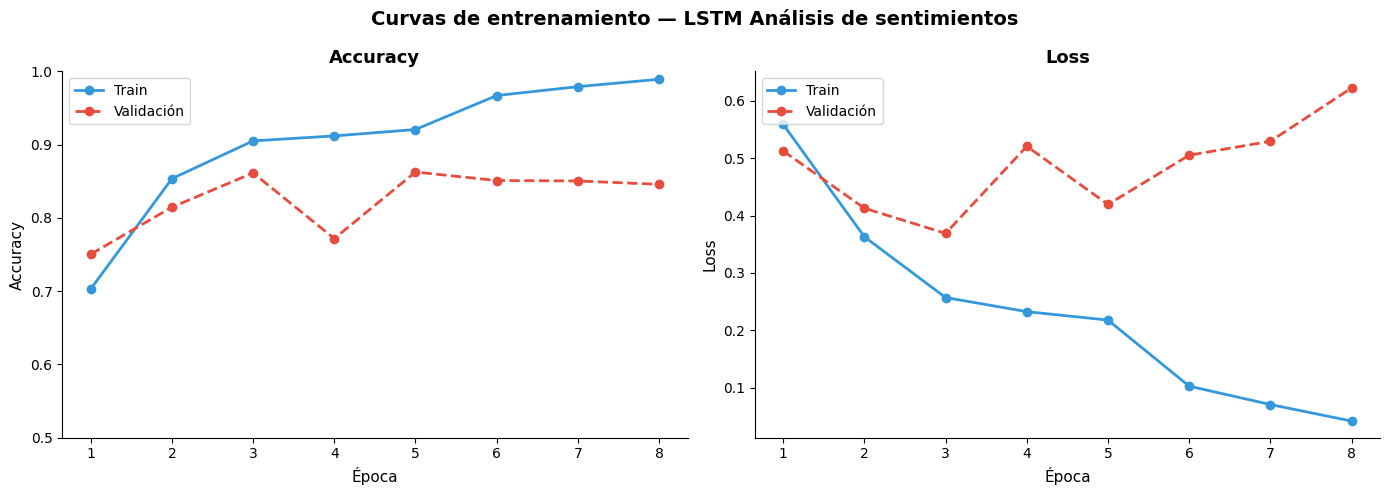

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Curvas de entrenamiento — LSTM Análisis de sentimientos',
             fontsize=14, fontweight='bold')

epochs = range(1, len(history.history['accuracy']) + 1)

axes[0].plot(epochs, history.history['accuracy'],
             color='#3498db', linewidth=2, marker='o', label='Train')
axes[0].plot(epochs, history.history['val_accuracy'],
             color='#e74c3c', linewidth=2, marker='o', linestyle='--', label='Validación')
axes[0].set_title('Accuracy', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Época', fontsize=11)
axes[0].set_ylabel('Accuracy', fontsize=11)
axes[0].legend()
axes[0].set_ylim(0.5, 1.0)
axes[0].spines['top'].set_visible(False)
axes[0].spines['right'].set_visible(False)

axes[1].plot(epochs, history.history['loss'],
             color='#3498db', linewidth=2, marker='o', label='Train')
axes[1].plot(epochs, history.history['val_loss'],
             color='#e74c3c', linewidth=2, marker='o', linestyle='--', label='Validación')
axes[1].set_title('Loss', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Época', fontsize=11)
axes[1].set_ylabel('Loss', fontsize=11)
axes[1].legend()
axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('curvas_entrenamiento.png', dpi=300, bbox_inches='tight')
plt.show()

#Evaluacion del modelo

In [17]:


loss, accuracy = model.evaluate(X_test, y_test, verbose=0)

print("=" * 50)
print(f"  Loss en test:     {loss:.4f}")
print(f"  Accuracy en test: {accuracy * 100:.1f}%")
print("=" * 50)

y_pred_prob = model.predict(X_test, verbose=0)
y_pred      = (y_pred_prob > 0.5).astype(int).flatten()

print("\nReporte de clasificación:")
print(classification_report(y_test, y_pred,
      target_names=['Negativa', 'Positiva']))

  Loss en test:     0.4553
  Accuracy en test: 84.9%

Reporte de clasificación:
              precision    recall  f1-score   support

    Negativa       0.88      0.81      0.84     12500
    Positiva       0.82      0.89      0.86     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



#Matriz confusion

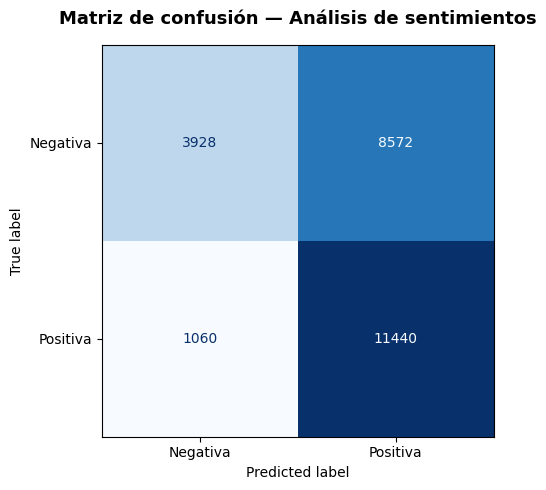

In [8]:
fig, ax = plt.subplots(figsize=(6, 5))

cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Negativa', 'Positiva'])
disp.plot(ax=ax, colorbar=False, cmap='Blues')

ax.set_title('Matriz de confusión — Análisis de sentimientos',
             fontsize=13, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('matriz_confusion.png', dpi=300, bbox_inches='tight')
plt.show()

#Curva RUC y AUC

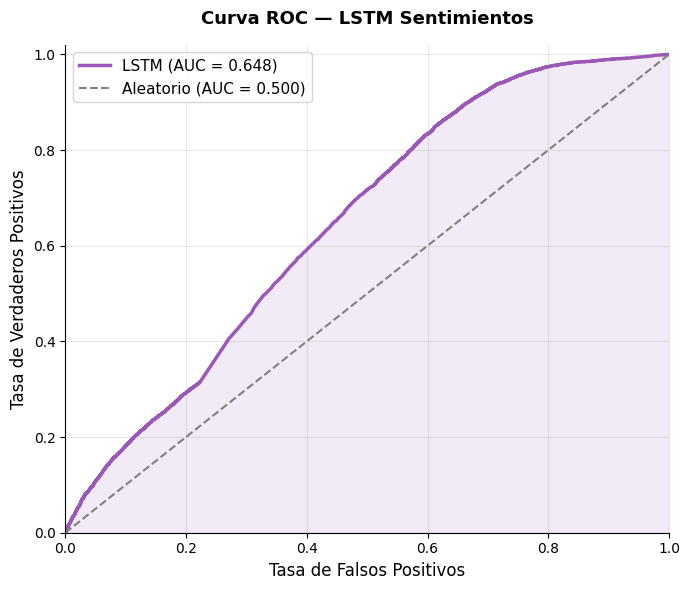

AUC Score: 0.648


In [9]:

from sklearn.metrics import roc_curve, roc_auc_score

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
auc_score   = roc_auc_score(y_test, y_pred_prob)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(fpr, tpr, color='#9b59b6', linewidth=2.5,
        label=f'LSTM (AUC = {auc_score:.3f})')
ax.fill_between(fpr, tpr, alpha=0.12, color='#9b59b6')
ax.plot([0,1], [0,1], color='gray', linewidth=1.5,
        linestyle='--', label='Aleatorio (AUC = 0.500)')

ax.set_xlabel('Tasa de Falsos Positivos', fontsize=12)
ax.set_ylabel('Tasa de Verdaderos Positivos', fontsize=12)
ax.set_title('Curva ROC — LSTM Sentimientos',
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=11)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('curva_roc.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"AUC Score: {auc_score:.3f}")

#Predecir nuevas resenas

In [10]:
def predecir_resena(texto):
    tokens = []
    for palabra in texto.lower().split():
        idx = word_index.get(palabra, 2)
        tokens.append(min(idx + 3, VOCAB_SIZE - 1))

    secuencia  = pad_sequences([tokens], maxlen=MAX_LEN,
                                padding='post', truncating='post')
    probabilidad = model.predict(secuencia, verbose=0)[0][0]
    sentimiento  = 'POSITIVA' if probabilidad > 0.5 else 'NEGATIVA'
    confianza    = probabilidad if probabilidad > 0.5 else 1 - probabilidad

    print(f"Reseña:      {texto[:80]}...")
    print(f"Sentimiento: {sentimiento}")
    print(f"Confianza:   {confianza * 100:.1f}%")
    print("-" * 50)

print("=== Predicción de reseñas nuevas ===\n")

predecir_resena("This movie was absolutely fantastic. The acting was brilliant and the story was amazing")
predecir_resena("Terrible film. Boring plot, bad acting, complete waste of time. I hated every minute")
predecir_resena("The movie was okay, nothing special but not terrible either")
predecir_resena("One of the best films I have ever seen. Masterpiece of cinema truly outstanding")

=== Predicción de reseñas nuevas ===

Reseña:      This movie was absolutely fantastic. The acting was brilliant and the story was ...
Sentimiento: POSITIVA
Confianza:   56.0%
--------------------------------------------------
Reseña:      Terrible film. Boring plot, bad acting, complete waste of time. I hated every mi...
Sentimiento: NEGATIVA
Confianza:   89.6%
--------------------------------------------------
Reseña:      The movie was okay, nothing special but not terrible either...
Sentimiento: NEGATIVA
Confianza:   89.6%
--------------------------------------------------
Reseña:      One of the best films I have ever seen. Masterpiece of cinema truly outstanding...
Sentimiento: POSITIVA
Confianza:   56.0%
--------------------------------------------------
